In [12]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats
import numpy as np

In [2]:
game_data = pd.read_csv("data/processed/steam_games.csv")
game_data.columns
game_data.head()
print(list(game_data.columns))

['appid', 'name', 'isfree', 'releasedate', 'releasedateprecision', 'releasedateraw', 'comingsoon', 'developers', 'publishers', 'genres', 'tags', 'controllersupport', 'players', 'players24h', 'players7d', 'playerstrend', 'playerschange24h', 'playerschange7d', 'playersrank', 'playersrankchange24h', 'avg30d', 'peak30d', 'peak30dat', 'low30d', 'low30dat', 'hoursplayed30d', 'peakalltime', 'peakalltimeat', 'last30days', 'last48h', 'playersupdatedat', 'metricsupdatedat', 'samplinginterval', 'playersstatus', 'hoursplayed30destimated', 'recommendations', 'metacritic', 'achievementscount', 'dlccount', 'requiredage', 'image', 'lastmodified', 'pricechangenumber', 'priceupdatedat', 'reviewsupdatedat', 'updatedat', 'prices.AU.country', 'prices.AU.currency', 'prices.AU.initial', 'prices.AU.final', 'prices.AU.discountpercent', 'prices.AU.formatted', 'prices.AU.convertedusd', 'prices.AU.onsale', 'prices.BR.country', 'prices.BR.currency', 'prices.BR.initial', 'prices.BR.final', 'prices.BR.discountpercen

In [3]:
# the most successful games by overall number of players
# it looks like players data is from the moment we queried the API, at least when it comes to players
successful_games = game_data.nlargest(10, 'players')
successful_games
# Print just the name and players columns
print(successful_games[['name', 'players']])

                                        name   players
21                          Counter-Strike 2  742806.0
18                                    Dota 2  526771.0
12506                    PUBG: BATTLEGROUNDS  122014.0
2013                                    Rust  113634.0
15                           Team Fortress 2   74554.0
5135          Tom Clancy's Rainbow Six Siege   71310.0
2944   The Witcher 3: Wild Hunt — Remastered   65469.0
1608                                Warframe   52579.0
1113                         Project Zomboid   50596.0
7791                                  VRChat   46081.0


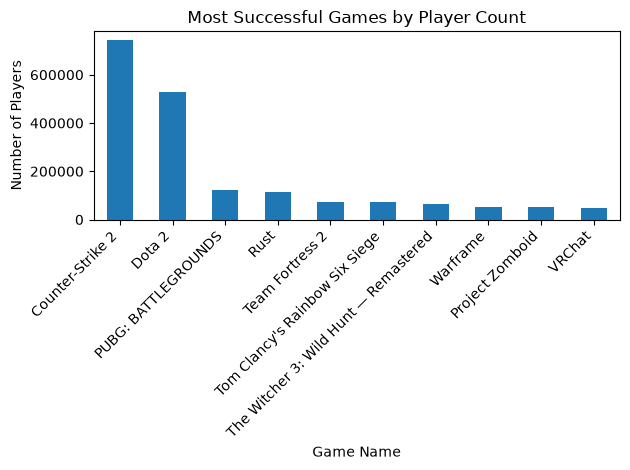

In [4]:
import matplotlib.pyplot as plt

# Create the bar chart
successful_games.plot.bar(x='name', y='players', rot=45, legend=False)

# Rotate by 45 degrees and align them properly under the bars
plt.xticks(rotation=45, ha='right')

# Add titles and labels
plt.title('Most Successful Games by Player Count')
plt.xlabel('Game Name')
plt.ylabel('Number of Players')

# Adjust layout so labels don't get cut off at the bottom
plt.tight_layout()

# Display the chart
plt.show()

In [5]:
# Most successful games by reviews
successful_games_by_reviews = game_data.nlargest(10, ['reviews.score', 'reviews.total'])
successful_games_by_reviews
# Print just the name and players columns
print(successful_games_by_reviews[['name', 'reviews.score', 'reviews.total']])

                                       name  reviews.score  reviews.total
1102                               Terraria              9        1558730
125                             Garry's Mod              9        1267733
17                            Left 4 Dead 2              9        1060484
7002                         Stardew Valley              9        1041491
1572                 Euro Truck Simulator 2              9         945785
2944  The Witcher 3: Wild Hunt — Remastered              9         897658
1796                             The Forest              9         683345
5440                          Hollow Knight              9         563383
1753                            Dying Light              9         496299
19                                 Portal 2              9         467376


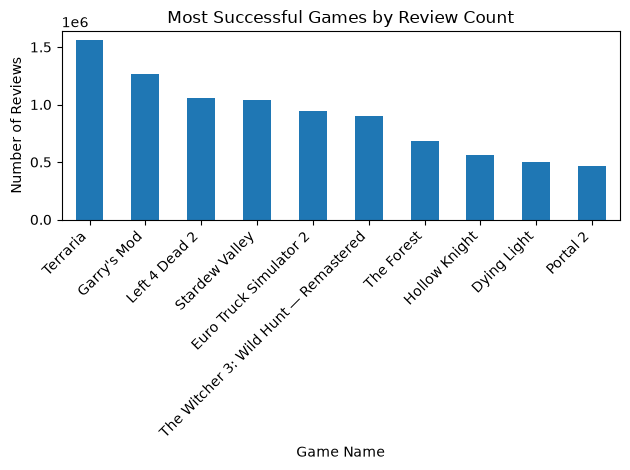

In [6]:
# Create the bar chart
successful_games_by_reviews.plot.bar(x='name', y='reviews.total', rot=45, legend=False)

# Rotate by 45 degrees and align them properly under the bars
plt.xticks(rotation=45, ha='right')

# Add titles and labels
plt.title('Most Successful Games by Review Count')
plt.xlabel('Game Name')
plt.ylabel('Number of Reviews')

# Adjust layout so labels don't get cut off at the bottom
plt.tight_layout()

# Display the chart
plt.show()

In [7]:
# the most successful games by overall number of players
# it looks like all the data is from the last 30 days, at least when it comes to players
successful_games = game_data.nlargest(10, 'peakalltime')
successful_games
# Print just the name and players columns
print(successful_games[['name', 'peakalltime']])

                      name  peakalltime
12506  PUBG: BATTLEGROUNDS    3236027.0
21        Counter-Strike 2    1818368.0
18                  Dota 2    1291328.0
1102              Terraria     486918.0
5790             Fallout 4     471955.0
10849    Life is Strange 2     468634.0
11623        HELLDIVERS™ 2     458208.0
1632                POSTAL     408008.0
11584    World of Warships     400538.0
5570            Kathy Rain     336132.0


In [8]:
# Main columns indicating player engagement
engagement_cols = [
    'avg30d',
    'peak30d',
    'players24h',
    'hoursplayed30d',
    'players',
    'peakalltime'
]

# Basic summary
game_data[engagement_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
avg30d,19374.0,189.501548,7.663314e+03,0.0,0.0,0.0,1.0,811711.0
peak30d,19374.0,368.133117,1.393993e+04,0.0,0.0,0.0,2.0,1452036.0
players24h,3384.0,1492.663416,2.691881e+04,0.0,3.0,11.0,59.0,1160588.0
hoursplayed30d,19374.0,136278.189068,5.517587e+06,0.0,0.0,0.0,493.0,584431920.0
players,19374.0,157.005471,6.818319e+03,0.0,0.0,0.0,0.0,742806.0
peakalltime,19374.0,1989.534428,3.138130e+04,0.0,0.0,0.0,176.0,3236027.0


In [28]:
zero_avg = game_data[game_data['avg30d'] == 0]

zero_avg[['name', 'avg30d', 'players24h', 'peak30d']].head(30)

# Compare player metrics for zero-average games
zero_avg[
    ['avg30d', 'players24h', 'peak30d', 'players', 'peakalltime']
].describe()

,avg30d,players24h,peak30d,players,peakalltime
count,13800.0,30.0,13800.000000,13800.0,13800.000000
mean,0.0,0.0,0.152899,0.0,154.381232
std,0.0,0.0,0.401225,0.0,2317.636229
min,0.0,0.0,0.000000,0.0,0.000000
25%,0.0,0.0,0.000000,0.0,0.000000
50%,0.0,0.0,0.000000,0.0,0.000000
75%,0.0,0.0,0.000000,0.0,0.000000
max,0.0,0.0,3.000000,0.0,180471.000000


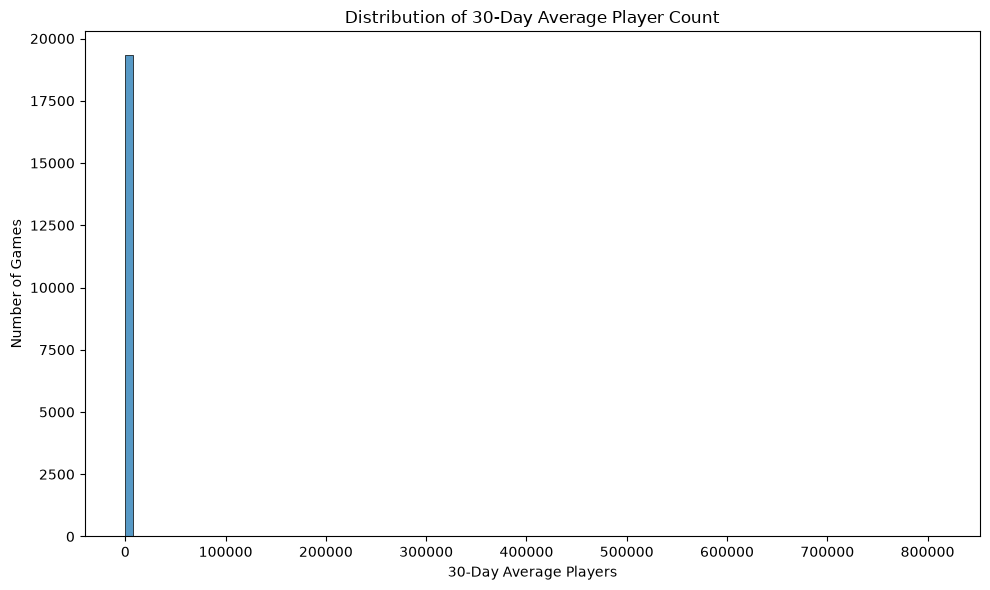

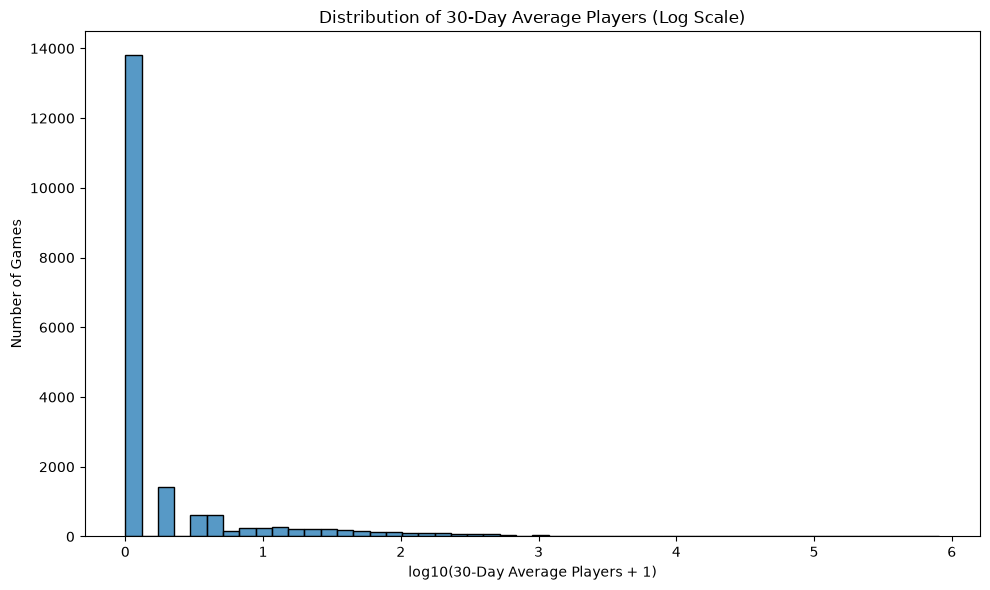

In [29]:
# Distribution of 30-day average player counts
plt.figure(figsize=(10, 6))

sns.histplot(
    data=game_data,
    x='avg30d',
    bins=100
)

plt.title('Distribution of 30-Day Average Player Count')
plt.xlabel('30-Day Average Players')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

# Above chart on a log scale because it's really bad
game_data['log_avg30d'] = np.log10(game_data['avg30d'] + 1)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=game_data,
    x='log_avg30d',
    bins=50
)

plt.title('Distribution of 30-Day Average Players (Log Scale)')
plt.xlabel('log10(30-Day Average Players + 1)')
plt.ylabel('Number of Games')

plt.tight_layout()
plt.show()

In [30]:
# How many games have at least one current player?
print("avg30d > 0:", (game_data['avg30d'] > 0).sum())

# How many have at least one player historically?
print("peakalltime > 0:", (game_data['peakalltime'] > 0).sum())

# How many have historical players but currently have zero?
historically_active_currently_zero = (
    (game_data['peakalltime'] > 0) &
    (game_data['avg30d'] == 0)
)

print(
    "Historical players but avg30d = 0:",
    historically_active_currently_zero.sum()
)

avg30d > 0: 5574
peakalltime > 0: 8888
Historical players but avg30d = 0: 3314


player_category
0                 13800
1–10               3298
11–100             1496
101–1,000           582
1,001–10,000        154
10,001–100,000       41
100,000+            629
Name: count, dtype: int64
player_category
0                 69.0
1–10              16.5
11–100             7.5
101–1,000          2.9
1,001–10,000       0.8
10,001–100,000     0.2
100,000+           3.1


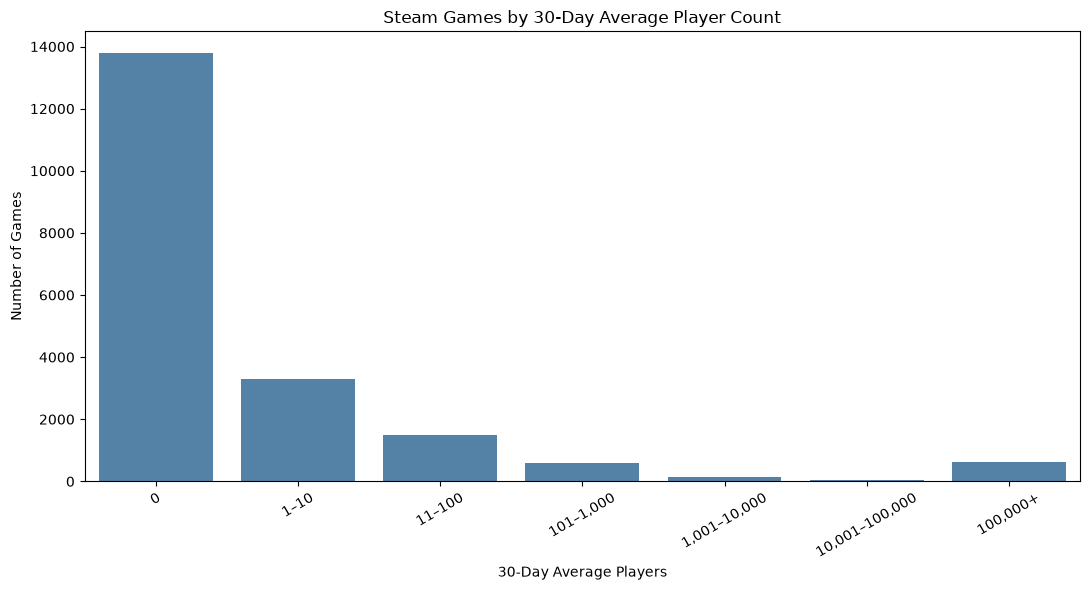

In [33]:
# Create meaningful player-count categories
def categorize_players(x):
    if x == 0:
        return '0'
    elif x <= 10:
        return '1–10'
    elif x <= 100:
        return '11–100'
    elif x <= 1000:
        return '101–1,000'
    elif x <= 10000:
        return '1,001–10,000'
    elif x <= 100000:
        return '10,001–100,000'
    else:
        return '100,000+'

game_data['player_category'] = (
    game_data['avg30d']
    .apply(categorize_players)
)

category_order = [
    '0',
    '1–10',
    '11–100',
    '101–1,000',
    '1,001–10,000',
    '10,001–100,000',
    '100,000+'
]

category_counts = (
    game_data['player_category']
    .value_counts()
    .reindex(category_order)
)

print(category_counts)

category_percentages = (
    category_counts / category_counts.sum() * 100
)

print(
    category_percentages.round(1).to_string()
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    color='steelblue'
)

plt.title('Steam Games by 30-Day Average Player Count')
plt.xlabel('30-Day Average Players')
plt.ylabel('Number of Games')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [34]:
# Remove games where avg30d is missing
analysis_data = game_data.dropna(
    subset=['avg30d']
).copy()

# Calculate the 90th percentile
success_threshold = analysis_data['avg30d'].quantile(0.90)

print(
    f"90th percentile of average 30-day players: "
    f"{success_threshold:,.0f}"
)

# Define highly successful games
analysis_data['highly_successful'] = (
    analysis_data['avg30d'] >= success_threshold
)

print("\nNumber of highly successful games:")
print(
    analysis_data['highly_successful'].sum()
)

print("\nPercentage highly successful:")
print(
    analysis_data['highly_successful'].mean() * 100
)

90th percentile of average 30-day players: 16

Number of highly successful games:
1942

Percentage highly successful:
10.02374316093734


In [36]:
# Lets see what the 'most successful' games are based on 30 day average player count
successful_games = (
    analysis_data[
        analysis_data['highly_successful']
    ]
    .sort_values('avg30d', ascending=False)
)

print(
    successful_games[
        ['name', 'avg30d', 'peak30d', 'peakalltime']
    ].head(30).to_string(index=False)
)

print(
    "Minimum avg30d among highly successful games:",
    successful_games['avg30d'].min()
)

print(
    "Maximum avg30d among highly successful games:",
    successful_games['avg30d'].max()
)

                                       name   avg30d   peak30d  peakalltime
                           Counter-Strike 2 811711.0 1452036.0    1818368.0
                                     Dota 2 574908.0  919002.0    1291328.0
                        PUBG: BATTLEGROUNDS 310923.0  788224.0    3236027.0
                                       Rust  83242.0  159010.0     259646.0
             Tom Clancy's Rainbow Six Siege  64298.0  120267.0     200476.0
                            Team Fortress 2  57205.0   90404.0     253225.0
                                   Warframe  55840.0  108836.0     181509.0
                            Project Zomboid  53429.0  100244.0     124506.0
              The Binding of Isaac: Rebirth  53111.0   92691.0     155966.0
                                War Thunder  52907.0  100117.0     125317.0
                             Stardew Valley  48769.0   92373.0     236614.0
                           Dead by Daylight  47079.0   75951.0     168845.0
            

In [37]:
# Checking what data has made it over here
candidate_variables = [
    'price',
    'positivepercent',
    'metacritic',
    'recommendations',
    'reviews.total',
    'reviews.score',
    'release_age',
    'isfree',
    'dlccount',
    'windows',
    'mac',
    'linux'
]

available_variables = [
    col for col in candidate_variables
    if col in analysis_data.columns
]

print(available_variables)

['metacritic', 'recommendations', 'reviews.total', 'reviews.score', 'isfree', 'dlccount']


In [46]:
# Lets see what distinguishes them and indicates people will come back
comparison_variables = [
    'metacritic',
    'recommendations',
    'reviews.total',
    'reviews.score',
    'isfree',
    'dlccount'
]

comparison = (
    analysis_data
    .groupby('highly_successful')[comparison_variables]
    .median()
    .T
)

comparison.columns = [
    'Other Games',
    'Highly Successful'
]

comparison['Difference'] = (
    comparison['Highly Successful']
    - comparison['Other Games']
)

comparison


,Other Games,Highly Successful,Difference
metacritic,71.0,79.0,8.0
recommendations,337.0,7255.0,6918.0
reviews.total,84.0,8929.5,8845.5
reviews.score,6.0,8.0,2.0
isfree,0.0,0.0,0.0
dlccount,0.0,1.0,1.0


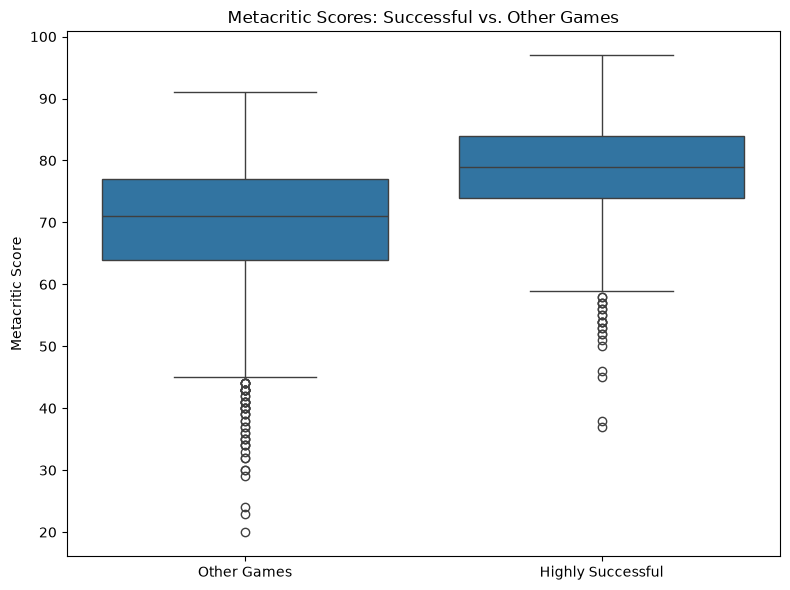

In [47]:
# The following boxplots are for displaying differences between large player
# counts and others in varying different things.
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_data,
    x='highly_successful',
    y='metacritic'
)

plt.xticks(
    [0, 1],
    ['Other Games', 'Highly Successful']
)

plt.title('Metacritic Scores: Successful vs. Other Games')
plt.xlabel('')
plt.ylabel('Metacritic Score')

plt.tight_layout()
plt.show()

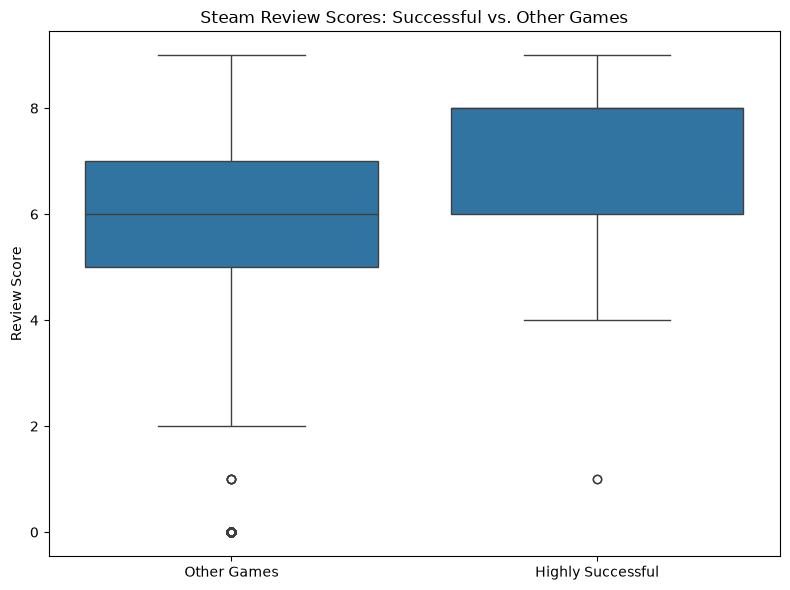

In [48]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_data,
    x='highly_successful',
    y='reviews.score'
)

plt.xticks(
    [0, 1],
    ['Other Games', 'Highly Successful']
)

plt.title('Steam Review Scores: Successful vs. Other Games')
plt.xlabel('')
plt.ylabel('Review Score')

plt.tight_layout()
plt.show()

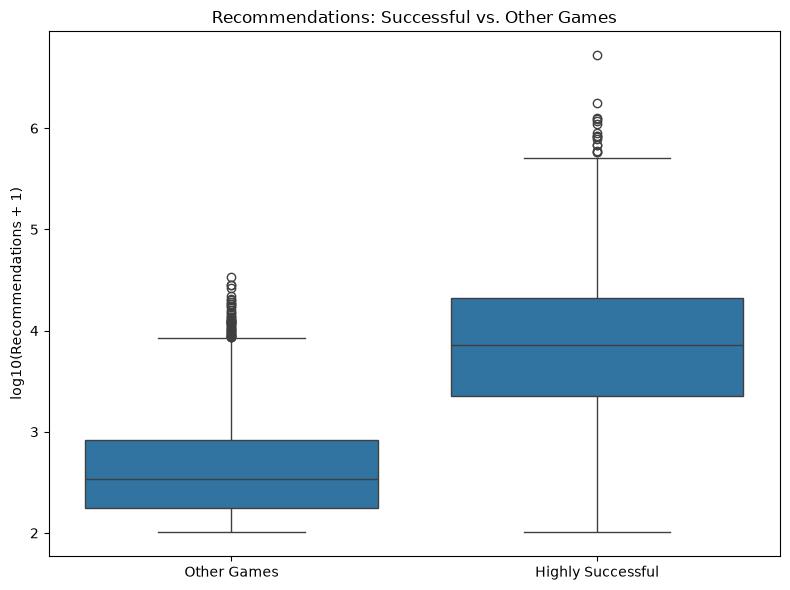

In [49]:
analysis_data['log_recommendations'] = np.log10(
    analysis_data['recommendations'].clip(lower=0) + 1
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_data,
    x='highly_successful',
    y='log_recommendations'
)

plt.xticks(
    [0, 1],
    ['Other Games', 'Highly Successful']
)

plt.title('Recommendations: Successful vs. Other Games')
plt.xlabel('')
plt.ylabel('log10(Recommendations + 1)')

plt.tight_layout()
plt.show()

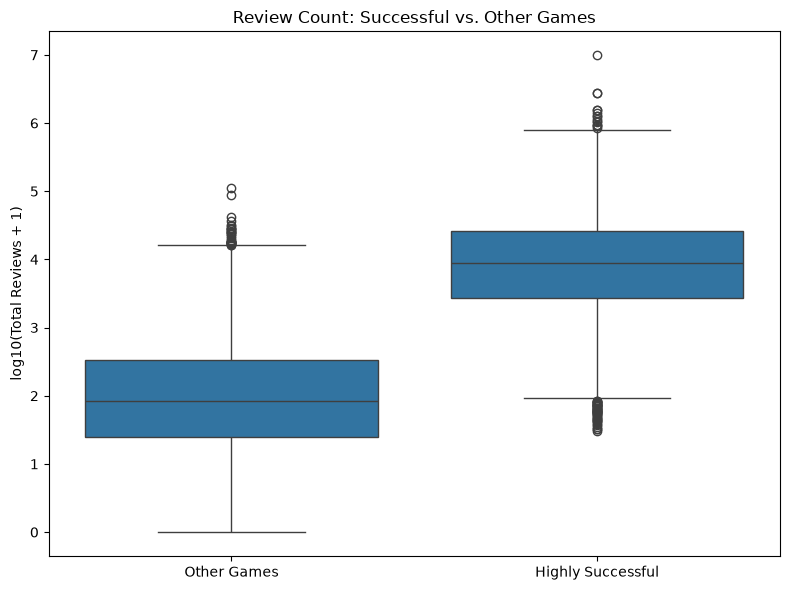

In [50]:
analysis_data['log_reviews'] = np.log10(
    analysis_data['reviews.total'].clip(lower=0) + 1
)

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_data,
    x='highly_successful',
    y='log_reviews'
)

plt.xticks(
    [0, 1],
    ['Other Games', 'Highly Successful']
)

plt.title('Review Count: Successful vs. Other Games')
plt.xlabel('')
plt.ylabel('log10(Total Reviews + 1)')

plt.tight_layout()
plt.show()

Other Games          10.0
Highly Successful    12.1
Name: isfree, dtype: float64


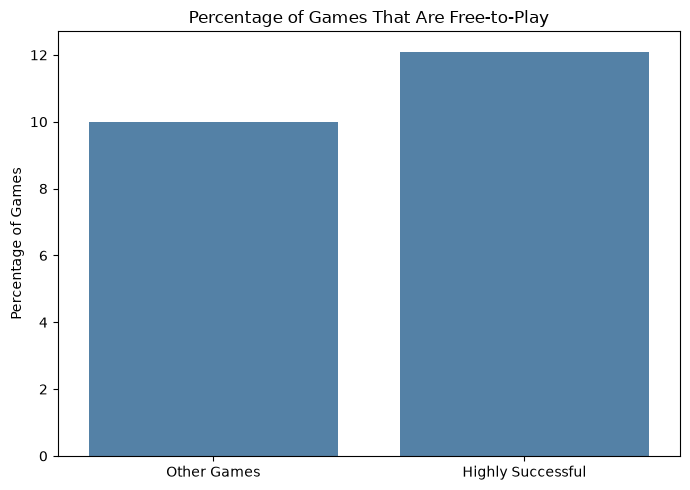

In [52]:
free_comparison = (
    analysis_data
    .groupby('highly_successful')['isfree']
    .mean()
    * 100
)

free_comparison.index = [
    'Other Games',
    'Highly Successful'
]

print(
    free_comparison.round(1)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=free_comparison.index,
    y=free_comparison.values,
    color='steelblue'
)

plt.title('Percentage of Games That Are Free-to-Play')
plt.xlabel('')
plt.ylabel('Percentage of Games')

plt.tight_layout()
plt.show()

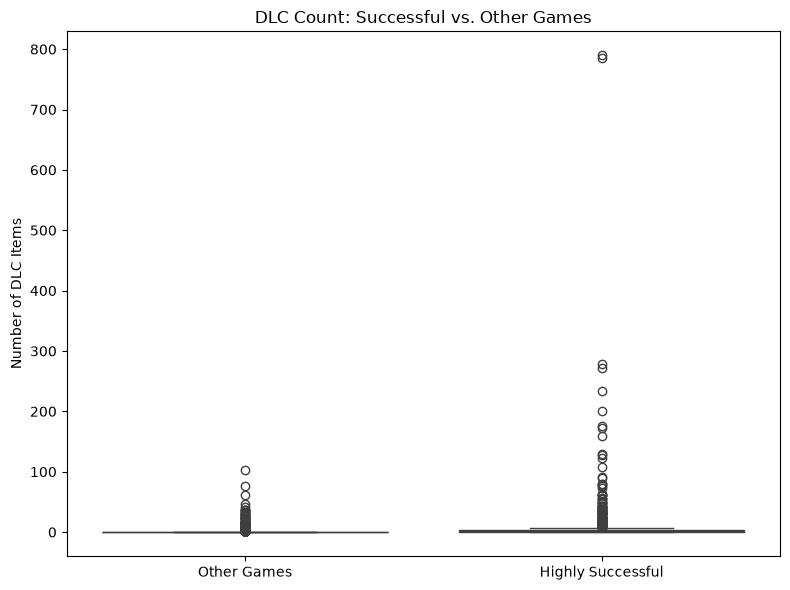

In [53]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_data,
    x='highly_successful',
    y='dlccount'
)

plt.xticks(
    [0, 1],
    ['Other Games', 'Highly Successful']
)

plt.title('DLC Count: Successful vs. Other Games')
plt.xlabel('')
plt.ylabel('Number of DLC Items')

plt.tight_layout()
plt.show()

In [54]:
from scipy.stats import mannwhitneyu

# Mann-Whitney U Test to see if there's a correlation
test_variables = [
    'metacritic',
    'recommendations',
    'reviews.total',
    'reviews.score',
    'dlccount'
]

test_results = []

for variable in test_variables:

    successful = analysis_data.loc[
        analysis_data['highly_successful'],
        variable
    ].dropna()

    other = analysis_data.loc[
        ~analysis_data['highly_successful'],
        variable
    ].dropna()

    statistic, p_value = mannwhitneyu(
        successful,
        other,
        alternative='two-sided'
    )

    test_results.append({
        'Variable': variable,
        'Successful Median': successful.median(),
        'Other Median': other.median(),
        'p-value': p_value
    })

statistical_comparisons = pd.DataFrame(
    test_results
)

statistical_comparisons

,Variable,Successful Median,Other Median,p-value
0,metacritic,79.0,71.0,1.110912e-102
1,recommendations,7255.0,337.0,0.000000e+00
2,reviews.total,8929.5,84.0,0.000000e+00
3,reviews.score,8.0,6.0,0.000000e+00
4,dlccount,1.0,0.0,2.000752e-295


In [57]:
# Correlation matrix to see what variables are associated with player engagement
correlation_variables = [
    'log_avg30d',
    'metacritic',
    'recommendations',
    'reviews.total',
    'reviews.score',
    'isfree',
    'dlccount'
]

correlation_variables = [
    col for col in correlation_variables
    if col in analysis_data.columns
]

correlation_data = analysis_data[
    correlation_variables
].copy()

correlation_matrix = correlation_data.corr()

correlation_matrix

,log_avg30d,metacritic,recommendations,reviews.total,reviews.score,isfree,dlccount
log_avg30d,1.000000,0.432865,0.330743,0.284059,0.319524,0.032454,0.187043
metacritic,0.432865,1.000000,0.192895,0.180589,0.550959,-0.002628,0.118506
recommendations,0.330743,0.192895,1.000000,0.943541,0.079874,0.060261,0.052707
reviews.total,0.284059,0.180589,0.943541,1.000000,0.053924,0.035638,0.050698
reviews.score,0.319524,0.550959,0.079874,0.053924,1.000000,0.090173,0.051665
isfree,0.032454,-0.002628,0.060261,0.035638,0.090173,1.000000,0.010959
dlccount,0.187043,0.118506,0.052707,0.050698,0.051665,0.010959,1.000000


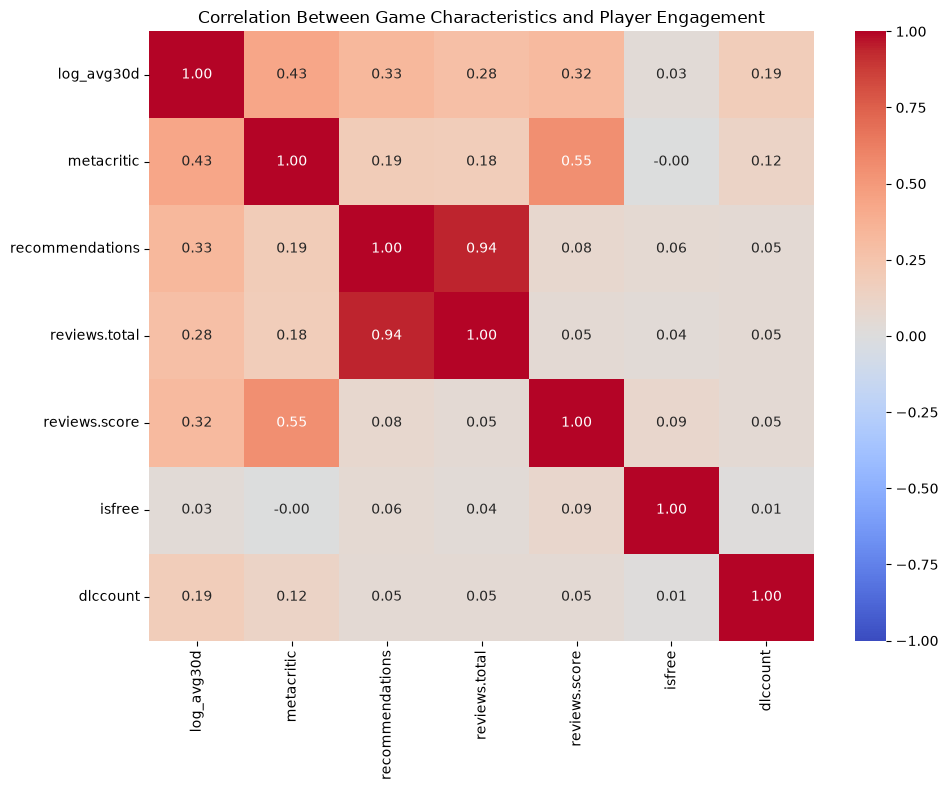

In [58]:
# Most important to look at is the log_avg30d column
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    'Correlation Between Game Characteristics and Player Engagement'
)

plt.tight_layout()
plt.show()

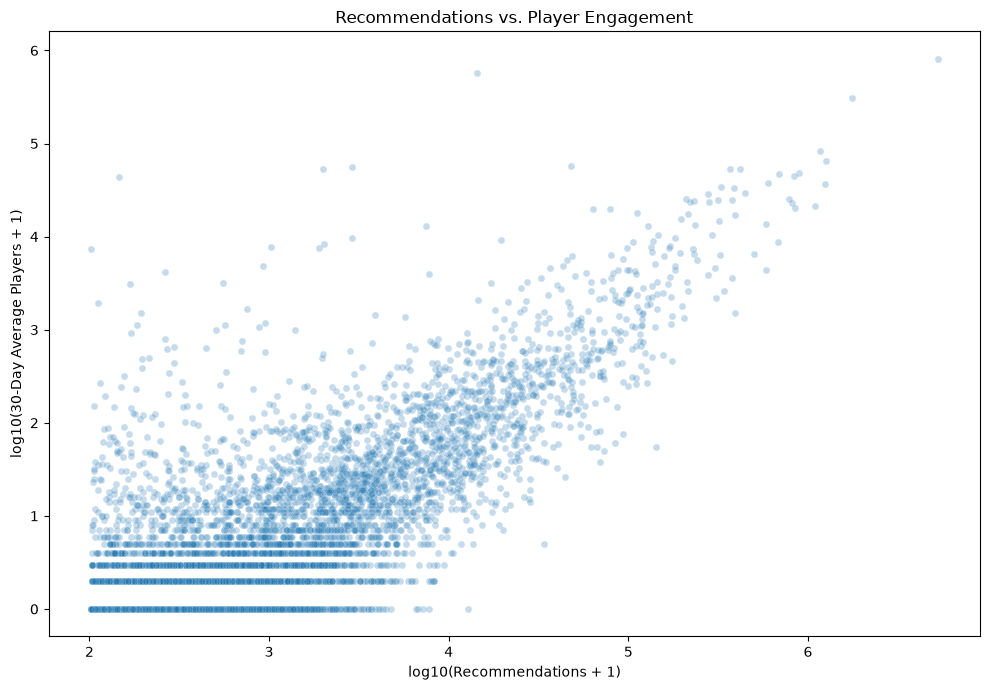

In [60]:
# The most compelling of the comparisons
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=analysis_data,
    x='log_recommendations',
    y='log_avg30d',
    alpha=0.25,
    s=25
)

plt.title(
    'Recommendations vs. Player Engagement'
)

plt.xlabel('log10(Recommendations + 1)')
plt.ylabel('log10(30-Day Average Players + 1)')

plt.tight_layout()
plt.show()

In [61]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [75]:
# MODEL A - Characteristics associated with engagement
# Define the data
model_a_variables = [
    'metacritic',
    'reviews.score',
    'isfree',
    'dlccount'
]

model_a_variables = [
    col for col in model_a_variables
    if col in analysis_data.columns
]

model_a_data = analysis_data[
    ['log_avg30d'] + model_a_variables
].copy()

model_a_data = model_a_data.dropna(
    subset=['log_avg30d']
)

X = model_a_data[model_a_variables]
y = model_a_data['log_avg30d']

# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Build the model
model_a = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    ),
    (
        'regression',
        LinearRegression()
    )
])

model_a.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['metacritic','reviews.score','isfree','dlccount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bo

In [65]:
# Model A evaluation
y_pred_a = model_a.predict(X_test)

r2_a = r2_score(
    y_test,
    y_pred_a
)

rmse_a = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_a
    )
)

print("Model A")
print("R²:", round(r2_a, 3))
print("RMSE:", round(rmse_a, 3))

Model A
R²: 0.16
RMSE: 0.598


In [66]:
# Examining the coefficients
model_a_regression = (
    model_a.named_steps['regression']
)

model_a_coefficients = pd.DataFrame({
    'Variable': model_a_variables,
    'Coefficient': model_a_regression.coef_
})

model_a_coefficients['Absolute Effect'] = (
    model_a_coefficients['Coefficient'].abs()
)

model_a_coefficients = (
    model_a_coefficients
    .sort_values(
        'Absolute Effect',
        ascending=False
    )
)

model_a_coefficients

,Variable,Coefficient,Absolute Effect
1,reviews.score,0.201082,0.201082
3,dlccount,0.109359,0.109359
0,metacritic,0.100714,0.100714
2,isfree,-0.003456,0.003456


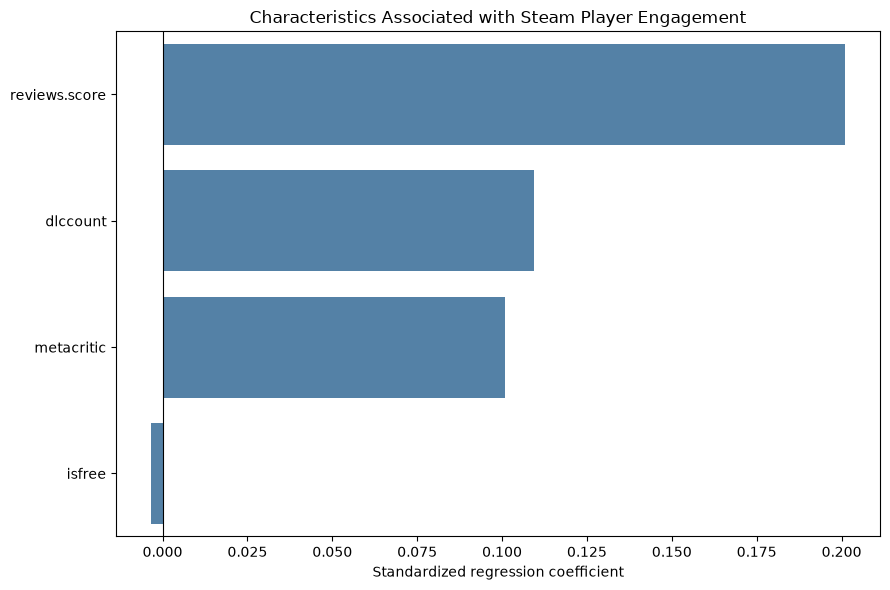

In [67]:
# Visualizing the above
plt.figure(figsize=(9, 6))

sns.barplot(
    data=model_a_coefficients,
    x='Coefficient',
    y='Variable',
    color='steelblue'
)

plt.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.title(
    'Characteristics Associated with Steam Player Engagement'
)

plt.xlabel('Standardized regression coefficient')
plt.ylabel('')

plt.tight_layout()
plt.show()

# The graph below shows that games with higher review scores tend to have
# higher player engagement after accounting for other characteristics

Model B
R²: 0.667
RMSE: 0.377


,Variable,Coefficient,Absolute Effect
4,log_reviews,0.355477,0.355477
5,log_recommendations,0.292659,0.292659
1,reviews.score,-0.077801,0.077801
0,metacritic,0.036808,0.036808
3,dlccount,0.030276,0.030276
2,isfree,0.015127,0.015127


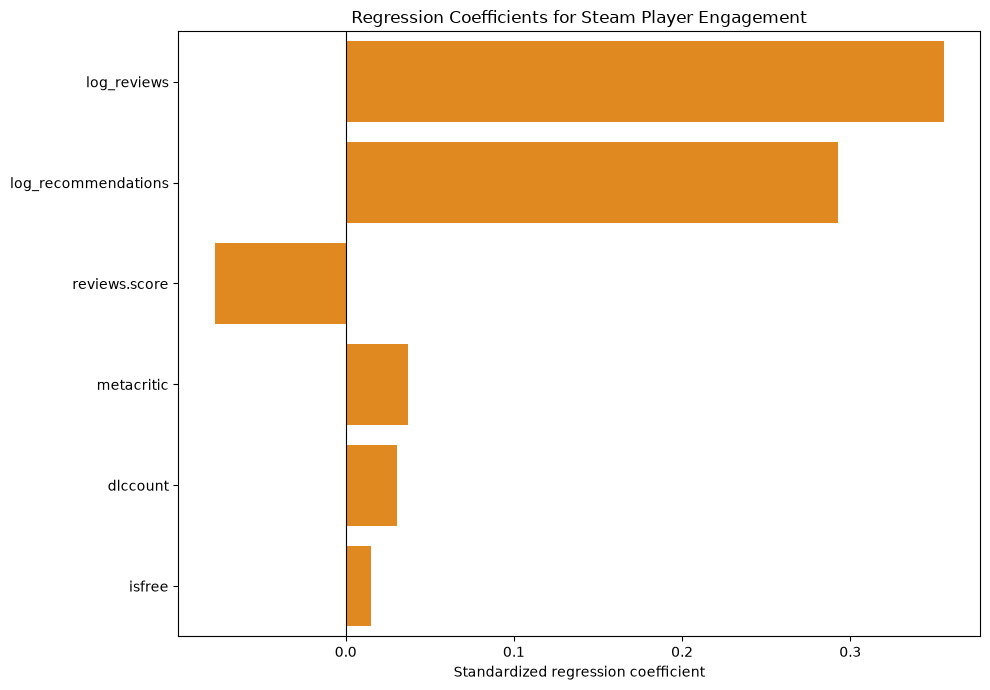

In [78]:
# MODEL B - Popularity-related variables
model_b_variables = [
    'metacritic',
    'reviews.score',
    'isfree',
    'dlccount',
    'reviews.total',
    'recommendations'
]

model_b_variables = [
    col for col in model_b_variables
    if col in analysis_data.columns
]

model_b_data = analysis_data[
    ['log_avg30d'] + model_b_variables
].copy()

model_b_data = model_b_data.dropna(
    subset=['log_avg30d']
)

# Log-transform the highly skewed variables
model_b_data['log_reviews'] = np.log10(
    model_b_data['reviews.total'].clip(lower=0) + 1
)

model_b_data['log_recommendations'] = np.log10(
    model_b_data['recommendations'].clip(lower=0) + 1
)

model_b_variables = [
    'metacritic',
    'reviews.score',
    'isfree',
    'dlccount',
    'log_reviews',
    'log_recommendations'
]

X = model_b_data[model_b_variables]
y = model_b_data['log_avg30d']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model_b = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    ),
    (
        'regression',
        LinearRegression()
    )
])

model_b.fit(
    X_train,
    y_train
)

y_pred_b = model_b.predict(X_test)

r2_b = r2_score(
    y_test,
    y_pred_b
)

rmse_b = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_b
    )
)

print("Model B")
print("R²:", round(r2_b, 3))
print("RMSE:", round(rmse_b, 3))

model_b_regression = (
    model_b.named_steps['regression']
)

model_b_coefficients = pd.DataFrame({
    'Variable': model_b_variables,
    'Coefficient': model_b_regression.coef_
})

model_b_coefficients['Absolute Effect'] = (
    model_b_coefficients['Coefficient'].abs()
)

model_b_coefficients = (
    model_b_coefficients
    .sort_values(
        'Absolute Effect',
        ascending=False
    )
)

display(model_b_coefficients)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=model_b_coefficients,
    x='Coefficient',
    y='Variable',
    color='darkorange'
)

plt.axvline(
    0,
    color='black',
    linewidth=0.8
)

plt.title(
    'Regression Coefficients for Steam Player Engagement'
)

plt.xlabel('Standardized regression coefficient')
plt.ylabel('')

plt.tight_layout()
plt.show()


In [69]:
# Compare the models
model_comparison = pd.DataFrame({
    'Model': [
        'Model A: Game characteristics',
        'Model B: + Reviews & Recommendations'
    ],
    'R²': [
        r2_a,
        r2_b
    ],
    'RMSE': [
        rmse_a,
        rmse_b
    ]
})

model_comparison

,Model,R²,RMSE
0,Model A: Game characteristics,0.160262,0.597623
1,Model B: + Reviews & Recommendations,0.666585,0.376572


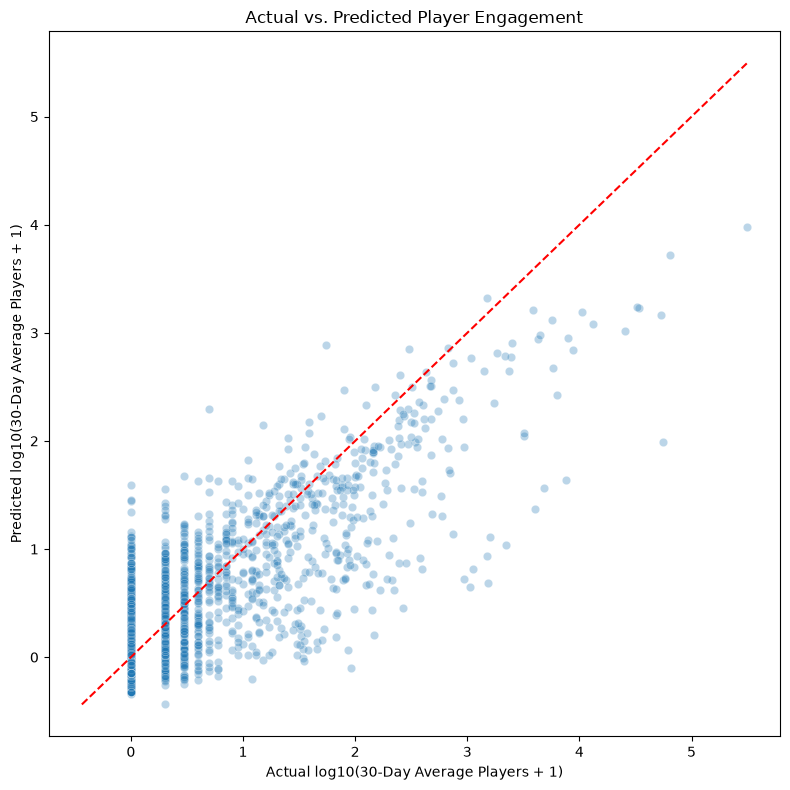

In [70]:
# Actual vs Predicted Player Engagement
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=y_pred_b,
    alpha=0.3
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    y_pred_b.min()
)

max_value = max(
    y_test.max(),
    y_pred_b.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    color='red'
)

plt.title(
    'Actual vs. Predicted Player Engagement'
)

plt.xlabel(
    'Actual log10(30-Day Average Players + 1)'
)

plt.ylabel(
    'Predicted log10(30-Day Average Players + 1)'
)

plt.tight_layout()
plt.show()

# Main takeaway 1: Metacritic, review score, free-to-play status, and DLC count
# explain about 16% of the variation in player engagement.
# Main takeaway 2: Reviews and recommendations are much more strongly associated
# with continued engagement, with review count being the strongest predictor in model B
# Overall: Games with larger review and recommendation footprints are strongly
# associated with higher current player engagement.

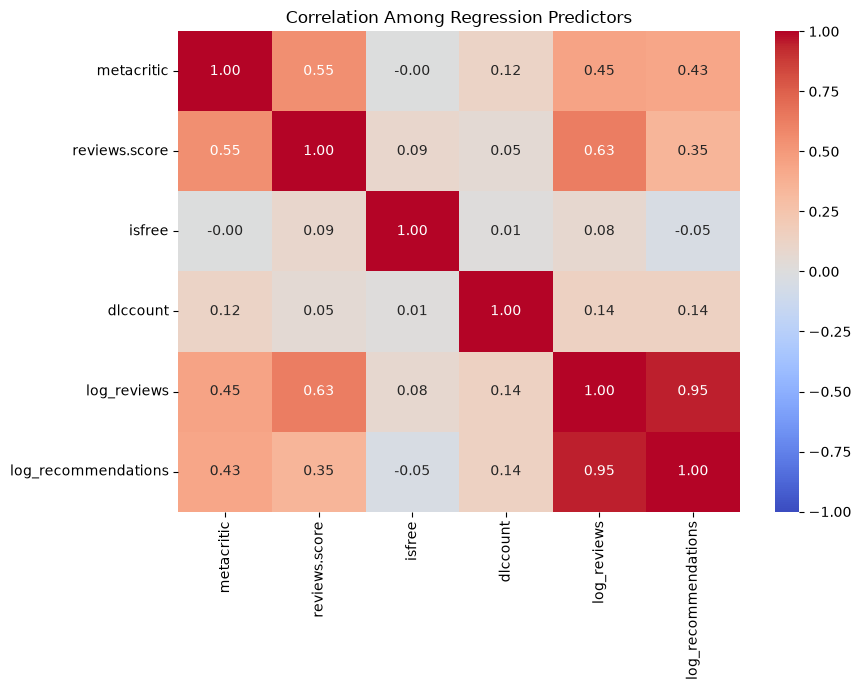

ModuleNotFoundError: No module named 'statsmodels'

In [80]:
# Check correlations among Model B predictors

model_b_correlation = model_b_data[
    model_b_variables
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    model_b_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Among Regression Predictors')

plt.tight_layout()
plt.show()